# Lab 2 — Inversion, orders, and a field built from a byte

**Maths for Post-Quantum Cryptography**, Chapter 2: *Modular Arithmetic and Finite Fields*

---

Three short pieces, none needing anything beyond the Python standard library
and a plot.

**Part A — two inverses, one comparison.** Implement modular inversion both
ways — extended Euclid, and Fermat exponentiation — and make the
data-dependence of the first, and the data-*independence* of the second,
visible rather than asserted.

**Part B — orders, primitive roots, and the standards' moduli.** Find
primitive roots modulo 11, 3329 and 8380417, and check exactly which of the
two standards' moduli have primitive 256th and 512th roots of unity — the
divisibility question that decides whether Chapter 4's transform is complete.

**Part C — $\mathbb{F}_{2^8}$ from scratch.** Build the byte field AES and the
Goppa-code decoders of Chapter 13 are constructed from, and check by brute
force that it really is a field.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — deliberately. Every algorithm here (extended Euclid, order by
factor-and-divide, primitive-root search, $\mathbb{F}_{2^8}$ arithmetic) is
written from scratch, because the point of this chapter is to see exactly what
each of these computes and how, not to call a library that hides it. Install
with `pip install numpy matplotlib`.

### How to use this notebook

Run it top to bottom once. Then look at **Your turn** near the end, which
corresponds to Exercise 2.10. Worked solutions for the pencil-and-paper
exercises (2.1–2.6, 2.11, 2.12) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a single
`_selftest()` that repeats all of them. CI runs this notebook on every commit;
if an assertion fires on your machine, that is a bug in the lab, not in your
understanding — please open an issue.

In [1]:
from __future__ import annotations

import random
from math import gcd

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Lab 1, so a figure lifted from
# either notebook matches what is on the page.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

random.seed(0)   # every "random" spot-check below is reproducible
print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — two inverses, one comparison

Two algorithms for computing $a^{-1} \bmod q$ from §2.2 and §2.3:

* **Extended Euclid** (Derivation 2.1) runs the Euclidean algorithm on the pair
  $(q, a)$ and carries coefficients $(s_i, t_i)$ alongside the remainders,
  stopping when the remainder hits 1 — the number of steps is the length of
  the continued-fraction expansion of $a/q$, and that length depends on $a$.
* **Fermat exponentiation** (Derivation 2.2) computes $a^{q-2} \bmod q$ by
  repeated squaring, for prime $q$ only — always the same fixed sequence of
  squarings and multiplications, regardless of $a$.

In [2]:
def xgcd_inverse(a: int, q: int) -> tuple[int, int]:
    """Modular inverse of a mod q via the extended Euclidean algorithm.

    Returns (inverse, steps), where `steps` is the number of division steps
    taken -- the quantity Sec 2.3's constant-time note calls data-dependent.
    Requires gcd(a, q) == 1.
    """
    r0, r1 = q, a % q
    s0, s1 = 0, 1
    steps = 0
    while r1 != 0:
        k = r0 // r1
        r0, r1 = r1, r0 - k * r1
        s0, s1 = s1, s0 - k * s1
        steps += 1
    if r0 != 1:
        raise ValueError(f"{a} is not invertible modulo {q}")
    return s0 % q, steps


def fermat_inverse(a: int, q: int) -> int:
    """Modular inverse of a mod prime q via Fermat's little theorem: a^(q-2) mod q.

    Python's three-argument pow does the square-and-multiply itself; the point
    of writing it as a call to pow(a, q - 2, q) rather than a hand-rolled loop
    is that the fixed exponent q - 2 is exactly what makes the operation
    count independent of a.
    """
    return pow(a, q - 2, q)


# Exhaustive agreement check over every unit modulo a handful of primes.
for p in (7, 11, 13, 97, 3329):
    for a in range(1, p):
        inv_x, _ = xgcd_inverse(a, p)
        inv_f = fermat_inverse(a, p)
        assert inv_x == inv_f, (p, a, inv_x, inv_f)
        assert (a * inv_x) % p == 1
print("xgcd_inverse and fermat_inverse agree on every unit mod 7, 11, 13, 97, 3329")

# 8380417 is too large to check exhaustively in a lab notebook; a random
# sample is enough to be confident the two agree there too.
Q_DILITHIUM = 8380417
for a in random.sample(range(1, Q_DILITHIUM), 2000):
    assert xgcd_inverse(a, Q_DILITHIUM)[0] == fermat_inverse(a, Q_DILITHIUM)
print("agreement confirmed on 2000 random units mod 8380417")

xgcd_inverse and fermat_inverse agree on every unit mod 7, 11, 13, 97, 3329
agreement confirmed on 2000 random units mod 8380417


### Exercise 2.7 — the iteration count, made visible

For $q = 3329$ (ML-KEM's modulus), plot the extended-Euclid iteration count
against $a$ for every $a \in \{1, \ldots, 3328\}$, and report the minimum,
maximum and mean. This is the data-dependence the constant-time note in
§2.3 describes in prose — here it is a picture.

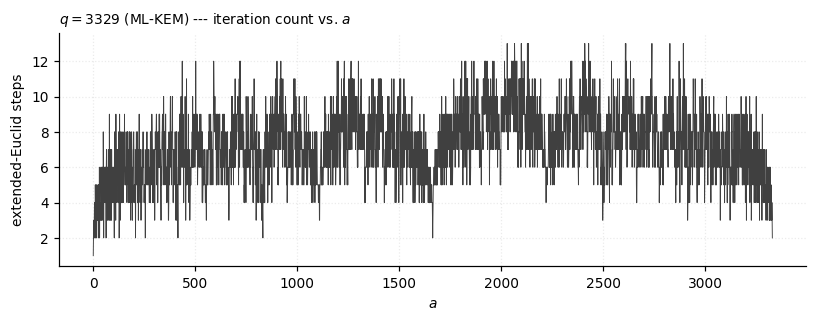

min = 1, max = 13, mean = 7.295


In [3]:
Q_KYBER = 3329
a_values = np.arange(1, Q_KYBER)
iterations = np.array([xgcd_inverse(int(a), Q_KYBER)[1] for a in a_values])

# Every inverse found along the way is still correct -- only the cost varies.
for a, inv in zip(a_values[:200], (xgcd_inverse(int(a), Q_KYBER)[0] for a in a_values[:200])):
    assert (int(a) * inv) % Q_KYBER == 1

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.plot(a_values, iterations, color="0.25", linewidth=0.6)
ax.set_xlabel("$a$")
ax.set_ylabel("extended-Euclid steps")
ax.set_title(f"$q = {Q_KYBER}$ (ML-KEM) --- iteration count vs. $a$",
             fontsize=9, loc="left")
plt.tight_layout(); plt.show()

lo, hi, mean = int(iterations.min()), int(iterations.max()), float(iterations.mean())
print(f"min = {lo}, max = {hi}, mean = {mean:.3f}")
assert lo != hi, "the whole point is that the count varies with a"

The count is nowhere near constant — the minimum is a single step (the
trivial case $a = 1$), the maximum is more than ten times that, and the mean
sits around 7. The *pattern* of highs and lows
(not just the count) leaks through timing if this loop is ever run on secret
data. That is precisely why §2.3 states the constant-time principle once and
refers back to it: Fermat inversion above takes the same $\lfloor \log_2(q-2)
\rfloor$ squarings for every single one of those 3328 values of $a$.

---

## Part B — orders, primitive roots, and the standards' moduli

`order(a, q)` could scan powers of $a$ one at a time until it sees 1 again —
that is what Chapter 1's `order` did for small composite $N$. But
Lagrange's theorem (Definition 2.3) says $\operatorname{ord}_q(a) \mid q - 1$,
and for $q = 8380417$ a brute-force scan could need up to 8.3 million
multiplications *per call*. Instead: factor $q - 1$ once, then divide the
exponent down by each prime factor as long as the identity still holds. This
is the standard trick, it needs only $O(\log q)$ modular exponentiations, and
it is exactly the divisibility structure §2.5 is about — made algorithmic.

In [4]:
def factorize(n: int) -> dict[int, int]:
    """Prime factorization of n by trial division. n is at most 8380416 here,
    so trial division up to sqrt(n) (~2895) is instant."""
    factors: dict[int, int] = {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors[d] = factors.get(d, 0) + 1
            n //= d
        d += 1 if d == 2 else 2
    if n > 1:
        factors[n] = factors.get(n, 0) + 1
    return factors


def order(a: int, q: int, factors_of_qm1: dict[int, int] | None = None) -> int:
    """Multiplicative order of a modulo prime q (Definition 2.3).

    ord_q(a) divides q - 1 (Lagrange), so start at n = q - 1 and, for each
    prime factor p, keep dividing n by p as long as a^(n/p) == 1 -- the
    largest divisor of q - 1 that still works is the order.
    """
    if gcd(a, q) != 1:
        raise ValueError(f"{a} is not a unit modulo {q}")
    if factors_of_qm1 is None:
        factors_of_qm1 = factorize(q - 1)
    n = q - 1
    for p in factors_of_qm1:
        while n % p == 0 and pow(a, n // p, q) == 1:
            n //= p
    return n


def is_primitive_root(g: int, q: int, factors_of_qm1: dict[int, int]) -> bool:
    """g is a primitive root mod prime q (Definition 2.4) iff g^((q-1)/p) != 1
    for every prime p dividing q - 1 -- the same factor-and-test idea as order()."""
    return all(pow(g, (q - 1) // p, q) != 1 for p in factors_of_qm1)


def smallest_primitive_root(q: int) -> int:
    factors_of_qm1 = factorize(q - 1)
    g = 2
    while not is_primitive_root(g, q, factors_of_qm1):
        g += 1
    return g


# Sanity check against Figure 2.1: 2 generates all of Z_11^x.
assert order(2, 11) == 10
assert smallest_primitive_root(11) == 2
print("order(2, 11) =", order(2, 11), " -- matches the necklace in Figure 2.1")

for q, name in [(11, "toy"), (3329, "ML-KEM"), (8380417, "ML-DSA")]:
    g = smallest_primitive_root(q)
    assert order(g, q) == q - 1              # a primitive root has order q - 1
    print(f"q = {q:>8} ({name:>7}): smallest primitive root g = {g}, "
          f"order(g, q) = {order(g, q)} = q - 1")

order(2, 11) = 10  -- matches the necklace in Figure 2.1
q =       11 (    toy): smallest primitive root g = 2, order(g, q) = 10 = q - 1
q =     3329 ( ML-KEM): smallest primitive root g = 3, order(g, q) = 3328 = q - 1
q =  8380417 ( ML-DSA): smallest primitive root g = 10, order(g, q) = 8380416 = q - 1


### Do 256th and 512th roots of unity exist?

A primitive $n$-th root of unity exists in $\Zq^\times$ exactly when $n \mid
q - 1$ (Definition 2.5, and the divisibility argument at the end of §2.5).
Check it directly for the two standards' moduli, and for the toy modulus 11.

In [5]:
def has_nth_root_of_unity(n: int, q: int) -> bool:
    """True iff Z_q^x contains a primitive n-th root of unity, i.e. n | q - 1."""
    return (q - 1) % n == 0


def element_of_order(n: int, q: int, g: int) -> int:
    """An element of Z_q^x with order exactly n, built from a primitive root g.

    ord(g^k) = ord(g) / gcd(ord(g), k) (Exercise 2.6); with g primitive and
    k = (q - 1) / n this is n exactly, provided n | q - 1.
    """
    if (q - 1) % n != 0:
        raise ValueError(f"{n} does not divide q - 1 = {q - 1}; no such element exists")
    return pow(g, (q - 1) // n, q)


print(f"{'q':>8} {'name':>8} {'q-1':>9}   256th?   512th?")
for q, name in [(11, "toy"), (3329, "ML-KEM"), (8380417, "ML-DSA")]:
    has256, has512 = has_nth_root_of_unity(256, q), has_nth_root_of_unity(512, q)
    print(f"{q:>8} {name:>8} {q-1:>9}   {str(has256):>6}   {str(has512):>6}")

# Exactly the claims made in the text after Figure 2.1:
assert not has_nth_root_of_unity(256, 11) and not has_nth_root_of_unity(512, 11)
assert has_nth_root_of_unity(256, 3329) and not has_nth_root_of_unity(512, 3329)
assert has_nth_root_of_unity(256, 8380417) and has_nth_root_of_unity(512, 8380417)

       q     name       q-1   256th?   512th?
      11      toy        10    False    False
    3329   ML-KEM      3328     True    False
 8380417   ML-DSA   8380416     True     True


### Exercise 2.8 — an element of order exactly 512

For $q = 8380417$, find the smallest primitive root and, separately, an
element of order exactly 512.

In [6]:
g = smallest_primitive_root(Q_DILITHIUM)
h = element_of_order(512, Q_DILITHIUM, g)
print(f"smallest primitive root mod {Q_DILITHIUM}: g = {g}")
print(f"an element of order exactly 512: h = g^((q-1)/512) mod q = {h}")

assert order(h, Q_DILITHIUM) == 512
assert pow(h, 512, Q_DILITHIUM) == 1
assert pow(h, 256, Q_DILITHIUM) != 1        # order is exactly 512, not a divisor of it

smallest primitive root mod 8380417: g = 10
an element of order exactly 512: h = g^((q-1)/512) mod q = 1921994


---

## Part C — $\mathbb{F}_{2^8}$ from scratch

Bytes, added by XOR and multiplied as polynomials over $\F_2$ modulo the
irreducible $f(x) = x^8 + x^4 + x^3 + x + 1$ (Derivation 2.4, §2.6) — the same
field AES's S-box is built from, packed as the 9-bit constant `0x11B`
(bit 8 set, then the coefficients of $x^4+x^3+x+1$ below it).

In [7]:
IRREDUCIBLE_AES = 0x11B   # x^8 + x^4 + x^3 + x + 1

def gf_add(a: int, b: int) -> int:
    """Addition in F_{2^8}: coefficientwise mod 2, i.e. bytewise XOR."""
    return a ^ b


def gf_mul(a: int, b: int, modulus: int = IRREDUCIBLE_AES) -> int:
    """Multiplication in F_{2^8}: carry-less (XOR) polynomial multiply, then
    reduce modulo `modulus` one bit at a time as the degree-8 term appears.

    This is the textbook shift-and-add binary-field multiply: process b bit
    by bit, XOR-ing in a shifted copy of a whenever that bit is set, and
    whenever a shift pushes a into degree 8, cancel that bit by XOR-ing with
    `modulus` (which has the same bit 8 set, plus the reduction terms).
    """
    result = 0
    while b:
        if b & 1:
            result ^= a
        carry = a & 0x80
        a = (a << 1) & 0xFF
        if carry:
            a ^= (modulus & 0xFF)
        b >>= 1
    return result


def gf_inverse(a: int, modulus: int = IRREDUCIBLE_AES) -> int:
    """Multiplicative inverse in F_{2^8} by brute-force search -- the point
    of this lab part is to check the field axioms hold, not to be fast."""
    if a == 0:
        raise ValueError("0 has no multiplicative inverse")
    for b in range(1, 256):
        if gf_mul(a, b, modulus) == 1:
            return b
    raise AssertionError(f"no inverse found for {a}: {hex(modulus)} may not be irreducible")


# Every non-zero byte must have an inverse -- this is the actual field check,
# not merely a plausibility check: if `modulus` were reducible, some non-zero
# byte would be a zero divisor and this loop would fail to find its inverse.
inverses = {a: gf_inverse(a) for a in range(1, 256)}
for a, inv in inverses.items():
    assert gf_mul(a, inv) == 1
print("every one of the 255 non-zero bytes has a multiplicative inverse "
      f"under f(x) = x^8+x^4+x^3+x+1 -- confirming it is irreducible")

every one of the 255 non-zero bytes has a multiplicative inverse under f(x) = x^8+x^4+x^3+x+1 -- confirming it is irreducible


### The full multiplication table

Exercise 2.9 asks for the $256 \times 256$ multiplication table and a check
that every row and column is a permutation of $\{0, \ldots, 255\}$ — the
finite-field analogue of the Latin-square property every group multiplication
table has (Lagrange's theorem again, one level up: multiplication by any
fixed non-zero $a$ is a bijection on $\F_{2^8}^\times$, by exactly the
injectivity argument of Derivation 2.2, now run on a field of size $2^8$
instead of $\Zq$).

all 255 non-zero rows and columns of the multiplication table are permutations of {1, ..., 255}


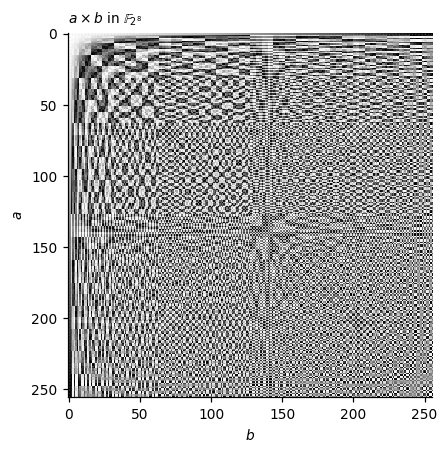

In [8]:
table = np.array([[gf_mul(a, b) for b in range(256)] for a in range(256)], dtype=np.uint16)

# Row 0 and column 0 are all zero (0 times anything is 0) -- exclude them and
# check the remaining 255 x 255 block of non-zero rows/columns.
nonzero_block = table[1:, 1:]
for row in nonzero_block:
    assert sorted(row.tolist()) == list(range(1, 256)), "a row is not a permutation"
for col in nonzero_block.T:
    assert sorted(col.tolist()) == list(range(1, 256)), "a column is not a permutation"
print("all 255 non-zero rows and columns of the multiplication table are "
      "permutations of {1, ..., 255}")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.imshow(table, cmap="Greys", interpolation="nearest")
ax.set_xlabel("$b$"); ax.set_ylabel("$a$")
ax.set_title("$a \\times b$ in $\\mathbb{F}_{2^8}$", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

### Associativity and distributivity, spot-checked

A full proof that this construction is a field belongs in Derivation 2.4, not
in a notebook — but a handful of random triples costs nothing and catches the
kind of bug the multiplication-table check above would not (that check only
confirms the *bijection* property; it says nothing about associativity).

In [9]:
for _ in range(200):
    a, b, c = (random.randint(0, 255) for _ in range(3))
    lhs_assoc = gf_mul(gf_mul(a, b), c)
    rhs_assoc = gf_mul(a, gf_mul(b, c))
    assert lhs_assoc == rhs_assoc, (a, b, c, "associativity failed")

    lhs_dist = gf_mul(a, gf_add(b, c))
    rhs_dist = gf_add(gf_mul(a, b), gf_mul(a, c))
    assert lhs_dist == rhs_dist, (a, b, c, "distributivity failed")

print("associativity and distributivity hold on 200 random triples")

associativity and distributivity hold on 200 random triples


---

## Your turn — Exercise 2.10: a different irreducible polynomial

Repeat Part C with a different irreducible degree-8 polynomial over $\F_2$
(search for one, or use another one you already know), and confirm the
resulting field is isomorphic to the first — do the two fields have the same
multiplication-table structure?

A polynomial $f$ of degree 8 is irreducible over $\F_2$ iff it has no factor
of degree 1 to 4 (any reducible degree-8 polynomial must have an irreducible
factor of degree $\le 4$, since two factors of degree $> 4$ would sum to more
than 8). The two helpers below do carry-less polynomial division over
$\F_2$ — bit-packed the same way as `IRREDUCIBLE_AES` above — so you can
use them to test candidates.

In [10]:
def poly_deg(p: int) -> int:
    return p.bit_length() - 1


def poly_mod_f2(a: int, b: int) -> int:
    """a mod b, as polynomials over F_2, bit-packed (coefficient of x^k is bit k)."""
    db = poly_deg(b)
    while a and poly_deg(a) >= db:
        a ^= b << (poly_deg(a) - db)
    return a


def is_irreducible_f2(f: int, degree: int) -> bool:
    """True iff the degree-`degree` polynomial f has no factor of degree
    1 to degree // 2."""
    for cand in range(2, 1 << (degree // 2 + 1)):
        if 1 <= poly_deg(cand) <= degree // 2 and poly_mod_f2(f, cand) == 0:
            return False
    return True


# --- Exercise 2.10 --------------------------------------------------------
# (a) Search 0x180 to 0x1FF (all bit-8-set candidates) for an irreducible
#     polynomial other than IRREDUCIBLE_AES = 0x11B.
# other_modulus = next(c for c in range(0x180, 0x200)
#                       if c != IRREDUCIBLE_AES and is_irreducible_f2(c, 8))

# (b) Build the multiplication table under `other_modulus`, the same way as
#     above, and confirm every non-zero byte still has an inverse.

# (c) An isomorphism between the two fields is a relabelling: a bijection
#     phi: {0,...,255} -> {0,...,255} with phi(a +_1 b) = phi(a) +_2 phi(b)
#     and phi(a *_1 b) = phi(a) *_2 phi(b). Since addition is the same XOR in
#     both fields, only the multiplication needs to match after relabelling.
#     One way in: find a root of `other_modulus` inside the AES field (an
#     element r with gf_mul chains satisfying f(r) = 0 under IRREDUCIBLE_AES
#     arithmetic), then map x |-> the polynomial-in-r representation of x.
#     Confirm the relabelled table equals the original.

---

## What to take away

Two inversion algorithms that always agree on the answer and never agree on
the cost: that gap, made visible in Part A, is the seed of the constant-time
discipline that runs through the rest of this book. Part B's divisibility
check — does $n \mid q - 1$? — is decided entirely by the modulus, before a
single coefficient is multiplied, and it is exactly what separates ML-KEM's
incomplete transform from ML-DSA's complete one in Chapter 4. Part C's field
of bytes is not a curiosity: it is the concrete object Chapter 13's HQC and
Classic McEliece decoders are built from.

Chapter 3 moves from $\Zq$ to the polynomial ring $R_q = \Zq[x]/(x^n+1)$ that
ML-KEM and ML-DSA actually compute in.

---

*Standards status referenced in this lab was verified on 16 August 2026. Live
status: https://mathsforeverything.com/pqc/standards*

In [11]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    for p in (7, 11, 13, 97, 3329):
        for a in range(1, p):
            inv_x, _ = xgcd_inverse(a, p)
            assert inv_x == fermat_inverse(a, p)
            assert (a * inv_x) % p == 1

    its = np.array([xgcd_inverse(int(a), Q_KYBER)[1] for a in range(1, Q_KYBER)])
    assert its.min() != its.max()

    assert order(2, 11) == 10 and smallest_primitive_root(11) == 2
    for q in (11, 3329, 8380417):
        g = smallest_primitive_root(q)
        assert order(g, q) == q - 1

    assert not has_nth_root_of_unity(256, 11) and not has_nth_root_of_unity(512, 11)
    assert has_nth_root_of_unity(256, 3329) and not has_nth_root_of_unity(512, 3329)
    assert has_nth_root_of_unity(256, 8380417) and has_nth_root_of_unity(512, 8380417)

    g = smallest_primitive_root(Q_DILITHIUM)
    h = element_of_order(512, Q_DILITHIUM, g)
    assert order(h, Q_DILITHIUM) == 512

    for a in range(1, 256):
        assert gf_mul(a, gf_inverse(a)) == 1
    nz = np.array([[gf_mul(a, b) for b in range(256)] for a in range(1, 256)])[:, 1:]
    for row in nz:
        assert sorted(row.tolist()) == list(range(1, 256))
    for col in nz.T:
        assert sorted(col.tolist()) == list(range(1, 256))

    for _ in range(50):
        a, b, c = (random.randint(0, 255) for _ in range(3))
        assert gf_mul(gf_mul(a, b), c) == gf_mul(a, gf_mul(b, c))
        assert gf_mul(a, gf_add(b, c)) == gf_add(gf_mul(a, b), gf_mul(a, c))

    return "all checks passed"

print(_selftest())

all checks passed
